# **Topic: Does Education Equally Lift? The Asymmetric Returns of Educational Attainment on Class Status across Social Groups in the United States**



### #  Group Members: Carter Bursick, Maria Gerlero, Kunchi Wu

## Introduction

Education has long been seen as the primary pathway to upward mobility in the United States. The idea is straightforward: more schooling leads to better jobs, higher income, and a higher social standing. But does this hold equally for everyone?

This project examines whether the returns of educational attainment on subjective class identification are consistent across social groups, or whether the same level of education produces systematically different outcomes depending on who you are. We focus on **subjective class identification** (`class_`) as our outcome, because it captures how individuals perceive their own social position — which does not always align with objective economic measures.

We use data from the **General Social Survey (GSS)**, covering seven survey waves from 2012 to 2024 with a total of 20,612 respondents. The GSS is a nationally representative survey of U.S. adults, and its repeated cross-sectional design allows us to track distributional patterns over time. Our core independent variable is `degree`, which records the highest educational credential attained.

The analysis is organized around three research questions:

- **RQ1** examines how `class_` distributions vary across `degree` groups and social groups, and how these patterns have shifted over time.
- **RQ2** uses machine learning models (Decision Tree and Random Forest) to identify which predictors matter most for `class_` identification, and tests whether those predictors carry different weight across subgroups.
- **RQ3** investigates how parental education and family income at age 16 predict respondents' class identification, with a focus on intergenerational patterns.

## Rationale for Variable Selection

**Why subjective class?** Objective measures like income and occupational prestige tell us about economic position. Subjective class identification tells us something different: how people locate themselves in the social hierarchy. Research in stratification consistently shows that subjective and objective class do not perfectly overlap. Using `class_` as our outcome lets us examine the social-psychological dimension of inequality, not just the material one.

**Why `degree` instead of `educ`?** `educ` records years of schooling as a continuous variable. `degree` records the highest credential earned. Credentials are what actually get recognized in labor markets and social contexts, so `degree` has clearer sociological meaning for studying the returns of education.

**Why 2012–2024?** The 2010-coded occupational prestige and socioeconomic index variables (`sei10`, `prestg10`) were introduced starting around 2010 and systematically collected from 2012 onward. Using pre-2012 data would require working with an older coding scheme that is not directly comparable. Our window of seven waves gives us enough observations to detect patterns over time while staying within a methodologically consistent dataset.

**Why were some variables dropped?** `getahead` and `wordsum` were entirely absent in the 2021 wave due to survey design changes. `kidssol` had over 70% non-substantive responses. `pasei10` and `masei10` had too many missing or unreliable values to be useful as predictors. Keeping these columns would have required dropping a large share of the sample or accepting unreliable imputations.

**A note on 2021.** In 2021, the GSS transitioned from in-person to web-based administration. This mode shift affects how respondents answer attitude and perception questions, including `class_`. Any patterns we observe around 2021 should be interpreted with this caveat in mind.

# Data Dictionary

| Variable   | Description |
|------------|------------|
| realinc    | Family income in constant dollars |
| coninc     | Family income in constant dollars |
| hispanic   | Hispanic specified |
| uscitzn    | Respondent is a U.S. citizen |
| wordsum    | Number of words correct in vocabulary test |
| ballot     | Ballot used for interview |
| wrkstat    | Labor force status |
| hrs1       | Number of hours worked last week |
| occ10      | Respondent's census occupation code (2010) |
| indus10    | Respondent's industry code (NAICS 2007) |
| marital    | Marital status |
| divorce    | Ever been divorced or separated |
| paocc10    | Father's census occupation code (2010) |
| paind10    | Father's industry code (NAICS 2007) |
| maocc10    | Mother's census occupation code (2010) |
| sibs       | Number of brothers and sisters |
| childs     | Number of children |
| age        | Age of respondent |
| educ       | Highest year of school completed |
| paeduc     | Father's (or oldest same-sex parent’s) education level |
| maeduc     | Mother's (or youngest same-sex parent’s) education level |
| degree     | Respondent's highest degree |
| padeg      | Father's highest degree |
| madeg      | Mother's highest degree |
| sex        | Respondent's sex |
| race       | Race of respondent |
| reg16      | Region of residence at age 16 |
| mobile16   | Geographic mobility since age 16 |
| family16   | Living with parents at age 16 |
| incom16    | Family income at age 16 |
| born       | Respondent born in this country |
| parborn    | Parents born in this country |
| granborn   | Number of grandparents born outside the U.S. |
| income     | Total family income |
| polviews   | Political views (liberal/conservative) |
| happy      | General happiness |
| health     | Self-reported health condition |
| life       | Life perception (exciting or dull) |
| jobfind    | Could respondent find an equally good job |
| rank       | Self-ranking of social position |
| satfin     | Satisfaction with financial situation |
| finalter   | Change in financial situation |
| finrela    | Opinion of family income |
| getahead   | Opinion on how people get ahead |
| parsol     | Living standard compared to parents |
| kidssol    | Children’s living standard compared to respondent |
| masei10    | Mother's socioeconomic index (2010) |
| papres10   | Father's occupational prestige score (2010) |
| pasei10    | Father's socioeconomic index (2010) |
| prestg10   | Respondent's occupational prestige score (2010) |
| sei10      | Respondent's socioeconomic index (2010) |
| id_        | Respondent ID number |
| wtssps     | Person post-stratification weight |
| year       | GSS survey year |
| class_     | Subjective class identification |

In [0]:
# Load packages
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pyspark.sql.functions as F
from pyspark.sql.functions import col
from pyspark.ml import Pipeline
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier, LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder
from pyspark.ml.regression import LinearRegression

# Initial Hive Table Creation
- This section of the notebook is responsible for creating and cleaning table(s) for the `GSS_Raw.csv` dataset

In [0]:
%sql
use hive_metastore;
use cbursick;
select current_catalog()

current_catalog()
hive_metastore


Create an initial Hive table for the full `GSS_Raw.csv` dataset and name the table `gss_raw`

This raw table will ensure that ALL data is included into a table, so we will later convert some STRING data into INT or DOUBLE data later on


In [0]:
%sql
DROP TABLE IF EXISTS gss_raw;
-- Columns we plan to drop later are still included here so Spark reads every column in the correct position.

CREATE TABLE IF NOT EXISTS gss_raw
(
    year     INT,
    id_      INT,
    wrkstat  STRING,
    hrs1     STRING,
    occ10    STRING,
    indus10  STRING,
    marital  STRING,
    divorce  STRING,
    paocc10  STRING,
    paind10  STRING,
    maocc10  STRING,
    sibs     STRING,
    childs   STRING,
    age      STRING,
    educ     STRING,
    paeduc   STRING,
    maeduc   STRING,
    degree   STRING,
    padeg    STRING,
    madeg    STRING,
    sex      STRING,
    race     STRING,
    reg16    STRING,
    mobile16 STRING,
    family16 STRING,
    incom16  STRING,
    born     STRING,
    parborn  STRING,
    granborn STRING,
    income   STRING,
    polviews STRING,
    happy    STRING,
    health   STRING,
    life     STRING,
    jobfind  STRING,
    class_   STRING,
    rank     STRING,
    satfin   STRING,
    finalter STRING,
    finrela  STRING,
    getahead STRING,
    parsol   STRING,
    kidssol  STRING,
    realinc  STRING,
    coninc   STRING,
    hispanic STRING,
    uscitzn  STRING,
    wordsum  STRING,
    ballot   STRING,
    prestg10 STRING,
    papres10 STRING,
    sei10    STRING,
    pasei10  STRING,
    masei10  STRING,
    wtssps   DOUBLE
)
USING CSV
LOCATION '/users/cbursick/GSS_Raw.csv'
OPTIONS (header "true", delimiter ",");

Preview data from `gss_raw`

In [0]:
%sql
SELECT *
FROM gss_raw
limit 10;

year,id_,wrkstat,hrs1,occ10,indus10,marital,divorce,paocc10,paind10,maocc10,sibs,childs,age,educ,paeduc,maeduc,degree,padeg,madeg,sex,race,reg16,mobile16,family16,incom16,born,parborn,granborn,income,polviews,happy,health,life,jobfind,class_,rank,satfin,finalter,finrela,getahead,parsol,kidssol,realinc,coninc,hispanic,uscitzn,wordsum,ballot,prestg10,papres10,sei10,pasei10,masei10,wtssps
2012,1,Working part time,15,Advertising sales agents,Advertising and related services,Never married,.i: Inapplicable,First-line supervisors of non-retail sales workers,"Drugs, sundries, and chemical and allied products, merchant wholesalers",.i: Inapplicable,1,0,22,4 years of college,4 years of college,4 years of college,Bachelor's,Graduate,Bachelor's,MALE,White,Northeast,"Same state, different city",Both own parents,ABOVE AVERAGE,YES,Both born in the U.S.,Four,"$25,000 or more","Moderate, middle of the road",Very happy,Good,Exciting,Somewhat easy,Upper class,3,Pretty well satisfied,Stayed same,ABOVE AVERAGE,"Hard work, luck equally important",.i: Inapplicable,.i: Inapplicable,155139.9731,178712.46494,Not Hispanic,.i: Inapplicable,7,Ballot a,38,48,61.5,57.5,-100.0,2.27573756427
2012,2,Working part time,30,Broadcast and sound engineering technicians and radio,Construction,Never married,.i: Inapplicable,.i: Inapplicable,.i: Inapplicable,Administrative services managers,2,0,21,12th grade,.i: Inapplicable,12th grade,High school,.i: Inapplicable,High school,MALE,White,Northeast,"Same state, same city",Mother only,ABOVE AVERAGE,YES,Both born in the U.S.,None,"$25,000 or more",Slightly conservative,Very happy,Excellent,Exciting,.i: Inapplicable,Middle class,4,Pretty well satisfied,Better,ABOVE AVERAGE,Hard work most important,Much better,Much better,155139.9731,178712.46494,Not Hispanic,.i: Inapplicable,.i: Inapplicable,Ballot c,43,.i: Inapplicable,57.3,-100.0,64.9,6.21568732508
2012,3,Working full time,60,Aerospace engineers,Air transportation,Married,NO,.i: Inapplicable,.i: Inapplicable,Teacher assistants,1,2,42,12th grade,.i: Inapplicable,3 years of college,High school,.i: Inapplicable,Associate/Junior college,MALE,Other,Northeast,Different state,Mother only,BELOW AVERAGE,YES,Neither born in the U.S.,Four,"$25,000 or more",Slightly conservative,Pretty happy,Good,Exciting,.i: Inapplicable,Middle class,6,More or less satisfied,Better,ABOVE AVERAGE,Luck most important,Much better,.d: Do not Know/Cannot Choose,58800.0,91920.0,"Another Hispanic, Latino, or Spanish origin",.i: Inapplicable,.i: Inapplicable,Ballot c,75,.i: Inapplicable,89.3,-100.0,26.1,1.59991586689
2012,4,Other,.i: Inapplicable,Accountants and auditors,Insurance carriers and related activities,Married,YES,Chief executives,"Pulp, paper, and paperboard mills",.i: Inapplicable,2,2,49,1 year of college,6 years of college,4 years of college,High school,Graduate,Bachelor's,FEMALE,White,Northeast,"Same state, different city",Both own parents,FAR ABOVE AVERAGE,YES,Both born in the U.S.,None,"$25,000 or more",Slightly conservative,Very happy,.i: Inapplicable,.i: Inapplicable,.i: Inapplicable,Upper class,4,Pretty well satisfied,Better,ABOVE AVERAGE,.i: Inapplicable,Somewhat worse,Somewhat worse,68600.0,107240.0,Not Hispanic,.i: Inapplicable,9,Ballot b,60,72,76.3,77.4,-100.0,1.19129409111
2012,5,Retired,.i: Inapplicable,"Bailiffs, correctional officers, and jailers","Justice, public order, and safety activities",Separated,.i: Inapplicable,"Managers, all other",Automotive repair and maintenance,"Tailors, dressmakers, and sewers",0,3,70,4 years of college,.d: Do not Know/Cannot Choose,12th grade,Bachelor's,Less than high school,High school,FEMALE,Black,Northeast,"Same state, same city",Mother and stepparent,BELOW AVERAGE,YES,Both born in the U.S.,None,"$25,000 or more",Liberal,Very happy,.i: Inapplicable,.i: Inapplicable,.i: Inapplicable,Lower class,5,Not satisfied at all,Worse,FAR BELOW AVERAGE,.i: Inapplicable,Much better,About the same,26950.0,42130.0,Not Hispanic,.i: Inapplicable,6,Ballot b,40,39,

In [0]:
%sql
SELECT COUNT(*) AS row_count
FROM gss_raw;

row_count
20612


# Model-Ready Table (`gss`)

Following Professor Zhang's recommendations, we transitioned from a simple data cleaning approach straight to a "Model-Ready" pipeline. This ensures that no observations are dropped due to missing values, maintaining our full sample size of 20612 rows for the regression analysis


## Cleaning Numeric Columns
For every quantitative feature (e.g., `age`, `hrs1`, `coninc`, etc.), we generated multiple columns to replace the original messy string data:
- **Numeric Placeholder** (`_numeric`): We extracted numeric digits using regular expressions to handle text like `"89+ hrs"` or `"8 or more"`. Any non-substantive response (e.g., `.i: Inapplicable`, `.n: No answer`, or `-100` for missing income) was assigned a placeholder value of `0.0`
- **Granular Missingness Indicators**: Instead of a single `_missing` flag, we created separate binary indicators (0 or 1) for each type of non-response, where applicable to the column:
  - **`_inapplicable`**: The question did not apply to this respondent (`.i`)
  - **`_no_answer`**: The respondent declined to answer (`.n`)
  - **`_dont_know`**: The respondent did not know (`.d`)
  - **`_skipped`**: The respondent skipped the question on the web survey (`.s`)

  These indicators tell the model that the `0.0` in the numeric column is a placeholder, not a true zero, allowing the regression to estimate a specific coefficient for each type of missingness. Columns with only a `-100` sentinel and no dot codes (e.g., `coninc`, `sei10`) retain a single `_missing` flag instead.

## Columns to be Dropped
We will be dropping `getahead`, `kidssol`, `wordsum`, `papres10`, `pasei10`, `realinc` and `masei10`
- Most of these columns have values that were `.y: Not Available in this Year`. We want to have plenty of data, but these columns had too many missing values to be considered useful in our analysis

We will partition the data based on the `year` column using Dynamic Partitioning for more efficient run-times.

At the same time, we are transitioning from a simple CSV to a partitioned Delta table to enable faster query performance and ensure data integrity during updates.

In [0]:
%sql
-- Enable Dynamic Partitioning
SET spark.sql.sources.partitionOverwriteMode=dynamic;
SET hive.exec.dynamic.partition=true;
SET hive.exec.dynamic.partition.mode=nonstrict;

key,value
hive.exec.dynamic.partition.mode,nonstrict


In [0]:
%sql
DROP TABLE IF EXISTS gss;

CREATE TABLE IF NOT EXISTS gss
USING DELTA
PARTITIONED BY (year)
AS SELECT
  -- All original columns except dropped and raw numeric ones
  * EXCEPT (kidssol, getahead, wordsum, pasei10, masei10, papres10, realinc, year,
            hrs1, coninc, age, childs, sibs, sei10, prestg10, granborn, rank),

  -- hrs1
  CASE WHEN hrs1 LIKE '.i%' THEN 1 ELSE 0 END                              AS hrs1_inapplicable,
  CASE WHEN hrs1 LIKE '.n%' THEN 1 ELSE 0 END                              AS hrs1_no_answer,
  CASE WHEN hrs1 LIKE '.d%' THEN 1 ELSE 0 END                              AS hrs1_dont_know,
  CASE WHEN hrs1 LIKE '.s%' THEN 1 ELSE 0 END                              AS hrs1_skipped,
  CASE WHEN hrs1 LIKE '.%' OR TRIM(hrs1) = '' OR hrs1 IS NULL THEN 0.0
       ELSE COALESCE(CAST(REGEXP_EXTRACT(hrs1, '(\\d+)', 1) AS DOUBLE), 0.0)
  END                                                                       AS hrs1_numeric,

  -- coninc (uses -100 as missing sentinel, no dot codes)
  CASE WHEN coninc IS NULL OR CAST(coninc AS DOUBLE) < 0 THEN 1 ELSE 0 END AS coninc_missing,
  CASE WHEN coninc IS NULL OR CAST(coninc AS DOUBLE) < 0 THEN 0.0
       ELSE CAST(coninc AS DOUBLE)
  END                                                                       AS coninc_numeric,

  -- age
  CASE WHEN age LIKE '.i%' THEN 1 ELSE 0 END                               AS age_inapplicable,
  CASE WHEN age LIKE '.n%' THEN 1 ELSE 0 END                               AS age_no_answer,
  CASE WHEN age LIKE '.%' OR TRIM(age) = '' OR age IS NULL THEN 0.0
       ELSE COALESCE(CAST(REGEXP_EXTRACT(age, '(\\d+)', 1) AS DOUBLE), 0.0)
  END                                                                       AS age_numeric,

  -- childs
  CASE WHEN childs LIKE '.i%' THEN 1 ELSE 0 END                            AS childs_inapplicable,
  CASE WHEN childs LIKE '.n%' THEN 1 ELSE 0 END                            AS childs_no_answer,
  CASE WHEN childs LIKE '.d%' THEN 1 ELSE 0 END                            AS childs_dont_know,
  CASE WHEN childs LIKE '.s%' THEN 1 ELSE 0 END                            AS childs_skipped,
  CASE WHEN childs LIKE '.%' OR TRIM(childs) = '' OR childs IS NULL THEN 0.0
       ELSE COALESCE(CAST(REGEXP_EXTRACT(childs, '(\\d+)', 1) AS DOUBLE), 0.0)
  END                                                                       AS childs_numeric,

  -- sibs
  CASE WHEN sibs LIKE '.i%' THEN 1 ELSE 0 END                              AS sibs_inapplicable,
  CASE WHEN sibs LIKE '.n%' THEN 1 ELSE 0 END                              AS sibs_no_answer,
  CASE WHEN sibs LIKE '.d%' THEN 1 ELSE 0 END                              AS sibs_dont_know,
  CASE WHEN sibs LIKE '.s%' THEN 1 ELSE 0 END                              AS sibs_skipped,
  CASE WHEN sibs LIKE '.%' OR TRIM(sibs) = '' OR sibs IS NULL THEN 0.0
       ELSE COALESCE(CAST(REGEXP_EXTRACT(sibs, '(\\d+)', 1) AS DOUBLE), 0.0)
  END                                                                       AS sibs_numeric,

  -- sei10 (uses -100 as missing sentinel, no dot codes)
  CASE WHEN sei10 IS NULL OR CAST(sei10 AS DOUBLE) < 0 THEN 1 ELSE 0 END  AS sei10_missing,
  CASE WHEN sei10 IS NULL OR CAST(sei10 AS DOUBLE) < 0 THEN 0.0
       ELSE CAST(sei10 AS DOUBLE)
  END                                                                       AS sei10_numeric,

  -- prestg10 (.i only, no other dot codes in the data)
  CASE WHEN prestg10 LIKE '.i%' THEN 1 ELSE 0 END                         AS prestg10_inapplicable,
  CASE WHEN prestg10 LIKE '.%' OR TRIM(prestg10) = '' OR prestg10 IS NULL THEN 0.0
       ELSE COALESCE(CAST(REGEXP_EXTRACT(prestg10, '(\\d+)', 1) AS DOUBLE), 0.0)
  END                                                                       AS prestg10_numeric,

  -- granborn (word-to-number mapping)
  CASE WHEN granborn LIKE '.i%' THEN 1 ELSE 0 END                          AS granborn_inapplicable,
  CASE WHEN granborn LIKE '.n%' THEN 1 ELSE 0 END                          AS granborn_no_answer,
  CASE WHEN granborn LIKE '.d%' THEN 1 ELSE 0 END                          AS granborn_dont_know,
  CASE WHEN granborn LIKE '.s%' THEN 1 ELSE 0 END                          AS granborn_skipped,
  CASE WHEN granborn LIKE '.%' OR TRIM(granborn) = '' OR granborn IS NULL THEN 0.0
       ELSE COALESCE(
           CASE granborn
               WHEN 'None'  THEN 0.0
               WHEN 'One'   THEN 1.0
               WHEN 'Two'   THEN 2.0
               WHEN 'Three' THEN 3.0
               WHEN 'Four'  THEN 4.0
           END, 0.0)
  END                                                                       AS granborn_numeric,

  -- rank
  CASE WHEN rank LIKE '.i%' THEN 1 ELSE 0 END                              AS rank_inapplicable,
  CASE WHEN rank LIKE '.n%' THEN 1 ELSE 0 END                              AS rank_no_answer,
  CASE WHEN rank LIKE '.d%' THEN 1 ELSE 0 END                              AS rank_dont_know,
  CASE WHEN rank LIKE '.s%' THEN 1 ELSE 0 END                              AS rank_skipped,
  CASE WHEN rank LIKE '.%' OR TRIM(rank) = '' OR rank IS NULL THEN 0.0
       ELSE COALESCE(CAST(REGEXP_EXTRACT(rank, '(\\d+)', 1) AS DOUBLE), 0.0)
  END                                                                       AS rank_numeric,

  year  -- Partitioned column

FROM gss_raw;

num_affected_rows,num_inserted_rows


As a result of the `gss` table creation above...

The original string columns are now explicitly excluded from the EXCEPT list, so only the `_numeric` and indicator columns remain - no redundant originals.

`coninc` and `sei10` only get a single `_missing` flag (not granular) because they have no dot codes - their only missingness signal is the -100 sentinel.

`prestg10` only gets _inapplicable since .i is the only dot code present in the data.

`.s: Skipped on Web` is treated as its own indicator where applicable - this is a real behavioral category (web vs. in-person respondents) that could matter in regression.

In [0]:
%sql
SELECT *
FROM gss
limit 10;

id_,wrkstat,occ10,indus10,marital,divorce,paocc10,paind10,maocc10,educ,paeduc,maeduc,degree,padeg,madeg,sex,race,reg16,mobile16,family16,incom16,born,parborn,income,polviews,happy,health,life,jobfind,class_,satfin,finalter,finrela,parsol,hispanic,uscitzn,ballot,wtssps,hrs1_inapplicable,hrs1_no_answer,hrs1_dont_know,hrs1_skipped,hrs1_numeric,coninc_missing,coninc_numeric,age_inapplicable,age_no_answer,age_numeric,childs_inapplicable,childs_no_answer,childs_dont_know,childs_skipped,childs_numeric,sibs_inapplicable,sibs_no_answer,sibs_dont_know,sibs_skipped,sibs_numeric,sei10_missing,sei10_numeric,prestg10_inapplicable,prestg10_numeric,granborn_inapplicable,granborn_no_answer,granborn_dont_know,granborn_skipped,granborn_numeric,rank_inapplicable,rank_no_answer,rank_dont_know,rank_skipped,rank_numeric,year
2348,Keeping house,Cooks,Elementary and secondary schools,Widowed,NO,"Farmers, ranchers, and other agricultural managers",Animal production,.i: Inapplicable,12th grade,8th grade,8th grade,High school,Less than high school,Less than high school,FEMALE,White,Northeast,"Same state, different city",Both own parents,AVERAGE,YES,"Mother yes, father no",.r: Refused,.d: Do not Know/Cannot Choose,Very happy,Good,Routine,.i: Inapplicable,Working class,More or less satisfied,Worse,BELOW AVERAGE,.i: Inapplicable,Not Hispanic,.i: Inapplicable,Ballot a,0.408201354335,1,0,0,0,0.0,1,0.0,0,0,79.0,0,0,0,0,6.0,0,0,0,0,6.0,0,13.6,0,33.0,0,0,0,0,2.0,0,0,0,0,5.0,2018
2347,Retired,Drafters,Elementary and secondary schools,Married,YES,General and operations managers,"Machinery manufacturing, n.e.c.",Financial managers,4 years of college,2 years of college,12th grade,High school,High school,High school,MALE,White,Northeast,Different state,Both own parents,ABOVE AVERAGE,YES,Both born in the U.S.,"$25,000 or more",Conservative,Very happy,.i: Inapplicable,.i: Inapplicable,.i: Inapplicable,Middle class,More or less satisfied,Stayed same,AVERAGE,About the same,Not Hispanic,.i: Inapplicable,Ballot b,1.36826644714,1,0,0,0,0.0,0,38555.0,0,0,72.0,0,0,0,0,2.0,0,0,0,0,1.0,0,62.7,0,47.0,0,0,0,0,0.0,0,0,0,0,3.0,2018
2346,Retired,Payroll and timekeeping clerks,Business support services,Married,YES,Construction managers,Construction,"Bookkeeping, accounting, and auditing clerks",12th grade,12th grade,2 years of college,High school,High school,Bachelor's,FEMALE,White,Northeast,"Same state, same city",Both own parents,BELOW AVERAGE,YES,Both born in the U.S.,"$25,000 or more","Moderate, middle of the road",Very happy,Excellent,Routine,.i: Inapplicable,Middle class,Pretty well satisfied,Stayed same,ABOVE AVERAGE,Much better,Not Hispanic,.i: Inapplicable,Ballot c,1.34296682252,1,0,0,0,0.0,0,70100.0,0,0,67.0,0,0,0,0,3.0,0,0,0,0,3.0,0,41.8,0,40.0,0,0,0,0,2.0,0,0,0,0,4.0,2018
2345,Working part time,Cashiers,Miscellaneous general merchandise stores,Married,NO,Miscellaneous agricultural workers,Animal production,.i: Inapplicable,12th grade,8th grade,8th grade,High school,Less than high school,Less than high school,FEMALE,White,Northeast,"Same state, same city",Both own parents,BELOW AVERAGE,YES,Both born in the U.S.,"$25,000 or more",Slightly conservative,Pretty happy,Excellent,Routine,Somewhat easy,Working class,More or less satisfied,Stayed same,BELOW AVERAGE,.i: Inapplicable,Not Hispanic,.i: Inapplicable,Ballot a,0.868645579429,0,0,0,0,36.0,0,22782.5,0,0,75.0,0,0,0,0,4.0,0,0,0,0,6.0,0,21.6,0,28.0,1,0,0,0,0.0,0,0,0,0,5.0,2018
2344,Working full time,Secretaries and administrative assistants,Not specified manufacturing industries,Divorced,.i: Inapplicable,Chief executives,"Accounting, tax preparation, bookkeeping, and payroll services",Retail salespersons,12th grade,12th grade,1 year of college,High school,High school,High school,FEMALE,White,Midwest,Different state,Mother and stepparent,AVERAGE,YES,Both born in the U.S.,.r: Refused,"Moderate, middle of the road",Pretty happy,Good,Routine,Not easy,Working class,Not satisfied at all,Better,BELOW AVERAGE,.i: Inapplicable,Puerto R

Check the amount of `NULL` values in the `gss` numeric data. We want to ensure that there are 0 `NULL` values

In [0]:
%sql
SELECT
  SUM(CAST(hrs1_numeric     IS NULL AS INT)) AS hrs1_numeric,
  SUM(CAST(coninc_numeric   IS NULL AS INT)) AS coninc_numeric,
  SUM(CAST(age_numeric      IS NULL AS INT)) AS age_numeric,
  SUM(CAST(childs_numeric   IS NULL AS INT)) AS childs_numeric,
  SUM(CAST(sibs_numeric     IS NULL AS INT)) AS sibs_numeric,
  SUM(CAST(sei10_numeric    IS NULL AS INT)) AS sei10_numeric,
  SUM(CAST(prestg10_numeric IS NULL AS INT)) AS prestg10_numeric,
  SUM(CAST(granborn_numeric IS NULL AS INT)) AS granborn_numeric,
  SUM(CAST(rank_numeric     IS NULL AS INT)) AS rank_numeric
FROM gss;

hrs1_numeric,coninc_numeric,age_numeric,childs_numeric,sibs_numeric,sei10_numeric,prestg10_numeric,granborn_numeric,rank_numeric
0,0,0,0,0,0,0,0,0


In [0]:
%sql
DESCRIBE EXTENDED gss;

col_name,data_type,comment
id_,int,null
wrkstat,string,null
occ10,string,null
indus10,string,null
marital,string,null
divorce,string,null
paocc10,string,null
paind10,string,null
maocc10,string,null
educ,string,null


# Data Exploring and Visualization
In this section, we aim to perform basic Exploratory Data Analytics (EDA) in order to better understand the data.

Along the way, we will make changes to our `gss` table as needed.

**Key Steps:**
1. **Descriptive Statistics**: Calculate summary statistics for numerical columns (e.g.: `hrs1_numeric`, `coninc_numeric`, `age_numeric`, `childs_numeric`, `sibs_numeric`, `sei10_numeric`, `prestg10_numeric`, `granborn_numeric`, `rank_numeric`). This helps us understand the distribution type and range of values.
2. **Bar Chart for Year Distribution**: Since our data is dynamically partitioned on the `year` column, we will visualize the distribution of survey responses over time. Doing so, we can analyze how how many respondents we have in each survey cycle.
3. **Identify Categorical Columns**: We will count the distinct values for text/string columns (e.g., `wrkstat`, `occ10`, `indus10`, `marital`, etc.).
4. **Analyzing Educational and Professional Background Data**: We will use bar charts to visualize respondents’ education levels and employment characteristics (employment status, industry, and occupation) using `educ`, `wrkstat`, `indus10`, and `occ10`.
5. **Analyzing "Missing" Data"**: We will use a bar chart to visualize how much data is "missing" (has coded variables) for each column. Doing so, we can get a better idea of which columns are more reliable and representative to the broader dataset

## 1. Descriptive Statistics

In [0]:
df = spark.sql("SELECT * FROM gss")

#1a) Basic describe (count, mean, stddev, min, max) on all `_numeric` columns
df.describe('hrs1_numeric', 'coninc_numeric', 'age_numeric', 'childs_numeric', 'sibs_numeric', 'sei10_numeric', 'prestg10_numeric', 'granborn_numeric', 'rank_numeric').display()

#1b) Extended summary on `_numeric` columns (includes quartiles)
df.summary('count','mean','stddev','min','25%','50%','75%','max') \
    .select('summary','hrs1_numeric', 'coninc_numeric', 'age_numeric', 'childs_numeric', 'sibs_numeric', 'sei10_numeric', 'prestg10_numeric', 'granborn_numeric', 'rank_numeric') \
    .display()



summary,hrs1_numeric,coninc_numeric,age_numeric,childs_numeric,sibs_numeric,sei10_numeric,prestg10_numeric,granborn_numeric,rank_numeric
count,20612,20612,20612,20612,20612,20612,20612,20612,20612
mean,22.610760721909568,44378.34940059331,48.1525810207646,1.7771201241994954,3.0155734523578497,45.830598680380476,42.59834077236561,1.05012,3.372889578886086
stddev,22.75411505085853,43415.21880950698,19.55444105056058,1.6390344522889833,1.8822758938258901,24.814152463988233,16.44054374084712,1.57683287248393,2.644439550353785
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,89.0,178712.46494,89.0,8.0,6.0,93.7,80.0,4.0,10.0


summary,hrs1_numeric,coninc_numeric,age_numeric,childs_numeric,sibs_numeric,sei10_numeric,prestg10_numeric,granborn_numeric,rank_numeric
count,20612,20612,20612,20612,20612,20612,20612,20612,20612
mean,22.610760721909568,44378.34940059331,48.1525810207646,1.7771201241994954,3.0155734523578497,45.83059868038048,42.59834077236561,1.05012,3.372889578886086
stddev,22.75411505085853,43415.21880950697,19.55444105056058,1.6390344522889833,1.8822758938258901,24.814152463988233,16.440543740847115,1.57683287248393,2.6444395503537845
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,11868.75,33.0,0.0,1.0,25.0,32.0,0.0,0.0
50%,20.0,32670.0,48.0,2.0,3.0,39.9,44.0,0.0,4.0
75%,40.0,63195.0,63.0,3.0,5.0,67.7,53.0,2.0,5.0
max,89.0,178712.46494,89.0,8.0,6.0,93.7,80.0,4.0,10.0


We don't observe any unusual values. We will continue on...

## 2. Bar Chart for Year Distribution

In [0]:
#2) Fetch and display the results of the `year` column in a DataFrame
df_year = spark.sql("SELECT year FROM gss")
display(df_year.orderBy(df_year.year))


year
2012
2012
2012
2012
2012
2012
2012
2012
2012
2012


Databricks visualization. Run in Databricks to view.

From the bar chart above, we noticed that there are data points in 2021 due to COVID-19 taking place in 2020 (there was no survey wave in 2020).

Survey responses grew larger post-COVID-19.

## 3. Identify Categorical Columns

In [0]:
# Unique value counts for string columns
string_cols = [name for name, dtype in df.dtypes
                if dtype == 'string']

# Compute distinct-value counts
unique_counts = []
for c in string_cols:
    cnt = df.select(col(c)).distinct().count()
    unique_counts.append((c, cnt))

# Turn into a SparkDataFrame
spark.createDataFrame(unique_counts, ['column', 'unique_count']).orderBy('column').display()



column,unique_count
ballot,3
born,6
class_,7
degree,8
divorce,6
educ,23
family16,12
finalter,6
finrela,8
happy,6


There are a couple of columns with 250+ unique values. We will preview these unique values to make sure everything looks okay

In [0]:
# Preview unique values of columns that have many unique values

# Columns to inspect
cols_to_inspect = ['indus10', 'maocc10', 'occ10', 'paind10', 'paocc10']

for c in cols_to_inspect:
    print(f"\n── {c} ──")
    df.select(col(c)).distinct().orderBy(c).show(truncate=False)


── indus10 ──
+--------------------------------------------------------------+
|indus10                                                       |
+--------------------------------------------------------------+
|.i:  Inapplicable                                             |
|.n:  No answer                                                |
|.s:  Skipped on Web                                           |
|Accounting, tax preparation, bookkeeping, and payroll services|
|Active duty military personnel, all other                     |
|Administration of economic programs and space research        |
|Administration of environmental quality and housing programs  |
|Administration of human resource programs                     |
|Advertising and related services                              |
|Aerospace product and parts manufacturing                     |
|Agricultural chemical manufacturing                           |
|Agricultural implement manufacturing                          |
|Air trans

Looking at a sample of the data from the output of the cell above, we don't see any unordinary values. We expect there to be many values for these columns due to the vast amount of industries, jobs, and role types.

## 4. Analyzing Educational and Professional Background Data

Shared Setup:

In [0]:
df = spark.sql("SELECT educ, wrkstat, indus10, occ10 FROM gss").toPandas()

for col in ["educ", "wrkstat", "indus10", "occ10"]:
    df = df[~df[col].astype(str).str.startswith(".")]
    df = df[df[col].notna()]

TOP_N = 15
educ_counts = df["educ"].value_counts().sort_index()
wrkstat_counts = df["wrkstat"].value_counts()
indus_counts = df["indus10"].value_counts().head(TOP_N)
occ_counts = df["occ10"].value_counts().head(TOP_N)

Education Level:
- We can see that many of the survey respondents either have completed high school with no further education (12th Grade), or completed their undergraduate degree with no further education (4 years of college)

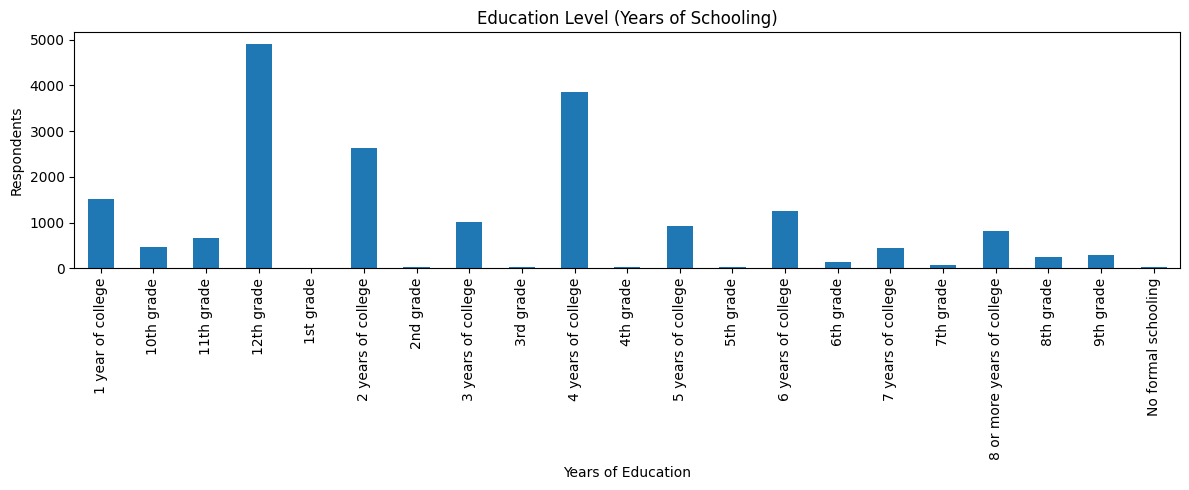

In [0]:
educ_counts.plot(kind="bar", figsize=(12, 5), title="Education Level (Years of Schooling)")
plt.xlabel("Years of Education")
plt.ylabel("Respondents")
plt.tight_layout()
plt.show()

Employment Status:
- Many of our respondents are working full time, but there are also a lot of retired individuals in the data

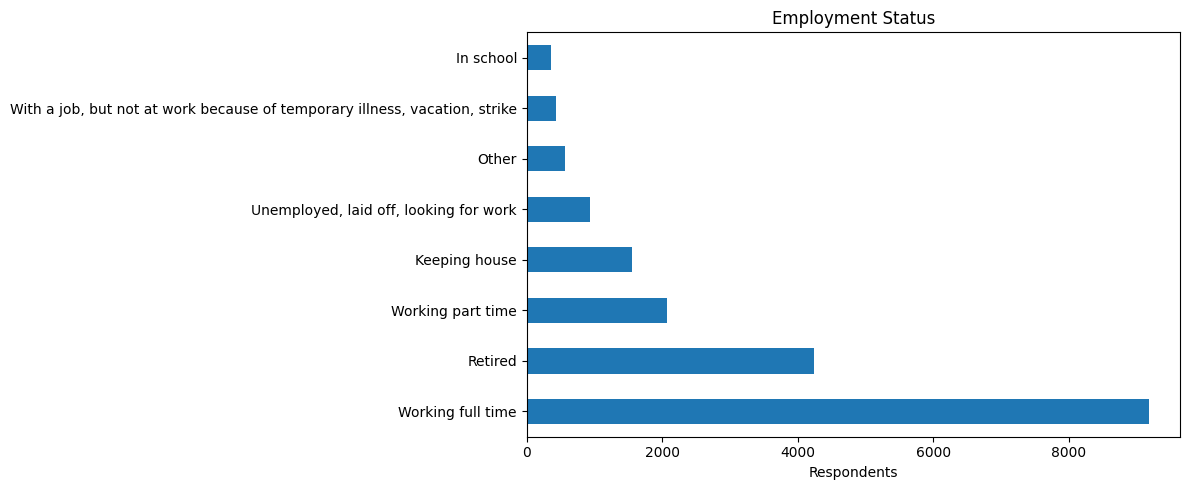

In [0]:
wrkstat_counts.plot(kind="barh", figsize=(12, 5), title="Employment Status")
plt.xlabel("Respondents")
plt.tight_layout()
plt.show()

Top 15 Industries:
- Many of the survey respondents work in the academic world
- Following academia, the respondents mainly work in Construction, Hospitals, or Restaurants/food service

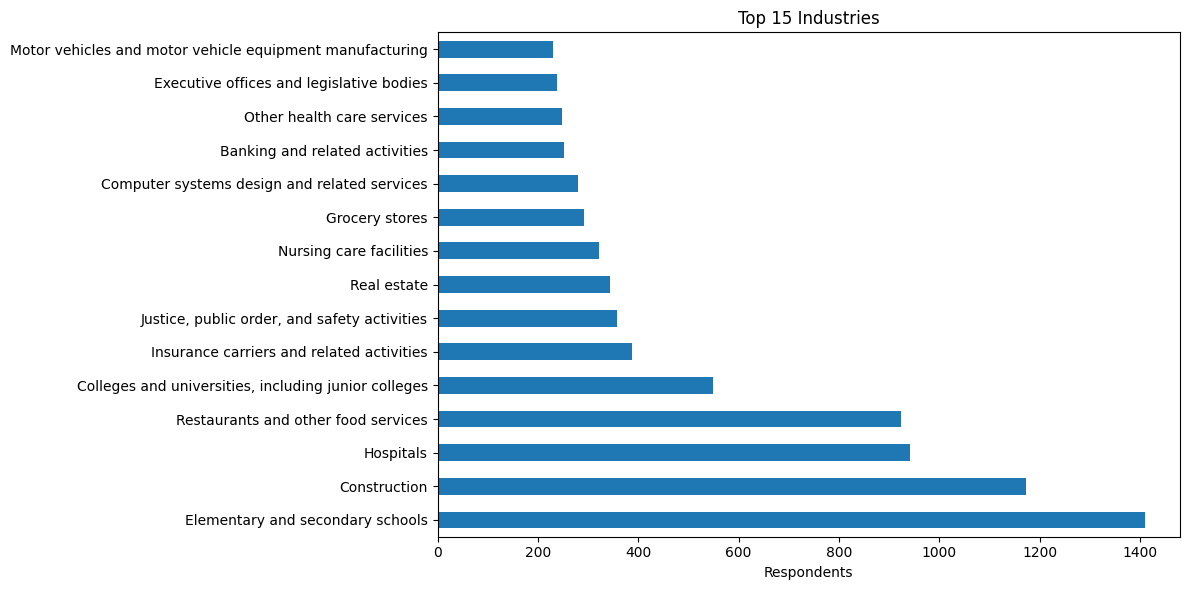

In [0]:
indus_counts.plot(kind="barh", figsize=(12, 6), title=f"Top {TOP_N} Industries")
plt.xlabel("Respondents")
plt.tight_layout()
plt.show()

Top 15 Occupations:
- Many of the survey responders are elementary/middle school teachers

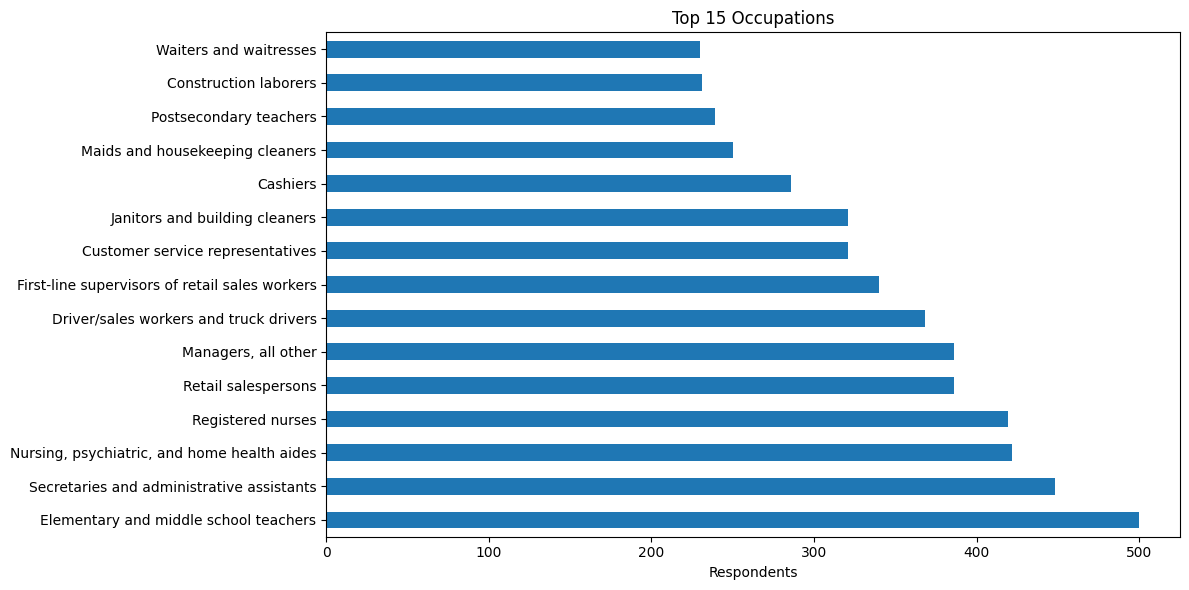

In [0]:
occ_counts.plot(kind="barh", figsize=(12, 6), title=f"Top {TOP_N} Occupations")
plt.xlabel("Respondents")
plt.tight_layout()
plt.show()

## 5. Visualize the amount of "missing" data

In [0]:
all_cols = spark.table("gss").columns
indicator_suffixes = ("_missing", "_inapplicable", "_no_answer", "_dont_know", "_skipped")
indicator_cols = [c for c in all_cols if c.endswith(indicator_suffixes)]

df_indicators = spark.sql(f"SELECT {', '.join(indicator_cols)} FROM gss").toPandas()
total = len(df_indicators)

# Build a DataFrame: rows = variables, columns = missing type
records = {}
for c in indicator_cols:
    # e.g. "hrs1_inapplicable" → variable="hrs1", mtype="inapplicable"
    *var_parts, mtype = c.rsplit("_", 1)
    var = "_".join(var_parts)
    records.setdefault(var, {})[mtype] = df_indicators[c].sum() / total * 100

df_plot = pd.DataFrame(records).T.fillna(0)

# Consistent column order
col_order = [c for c in ["inapplicable", "no_answer", "dont_know", "skipped", "missing"] if c in df_plot.columns]
df_plot = df_plot[col_order].sort_values("inapplicable", ascending=True)

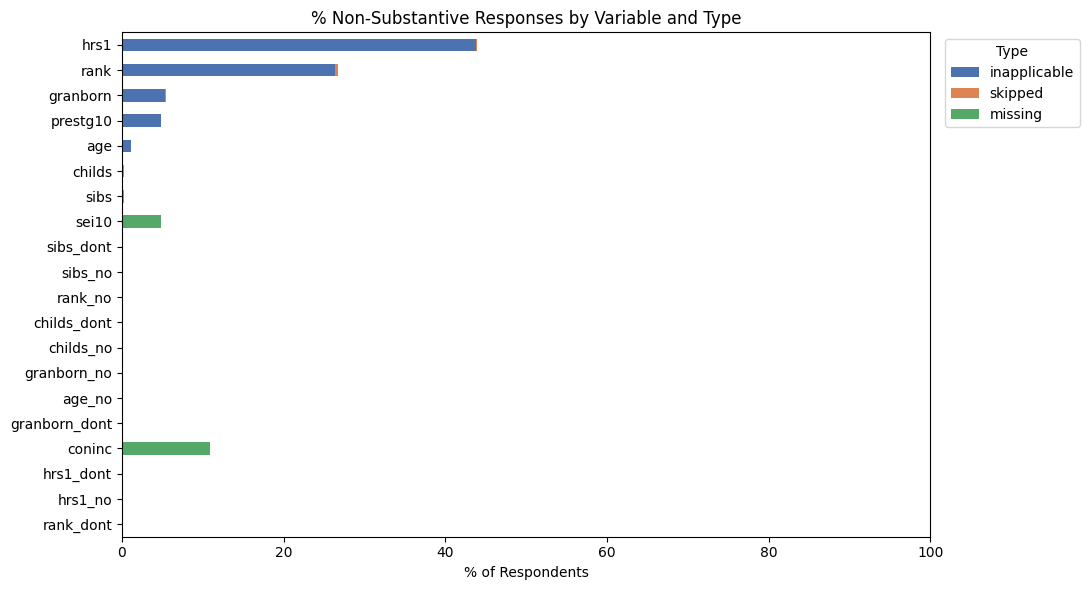

In [0]:
df_plot.plot(kind="barh", figsize=(11, 6), stacked=True,
             title="% Non-Substantive Responses by Variable and Type",
             color=["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"])
plt.xlabel("% of Respondents")
plt.xlim(0, 100)
plt.legend(title="Type", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

Looking at our output above, we can see that `hrs1` and `rank` are filled with many inapplicable values

## Research Question 1

**RQ1: How do patterns of subjective class identification vary across education levels and social groups, and how have these patterns shifted over time (2012–2024)?**

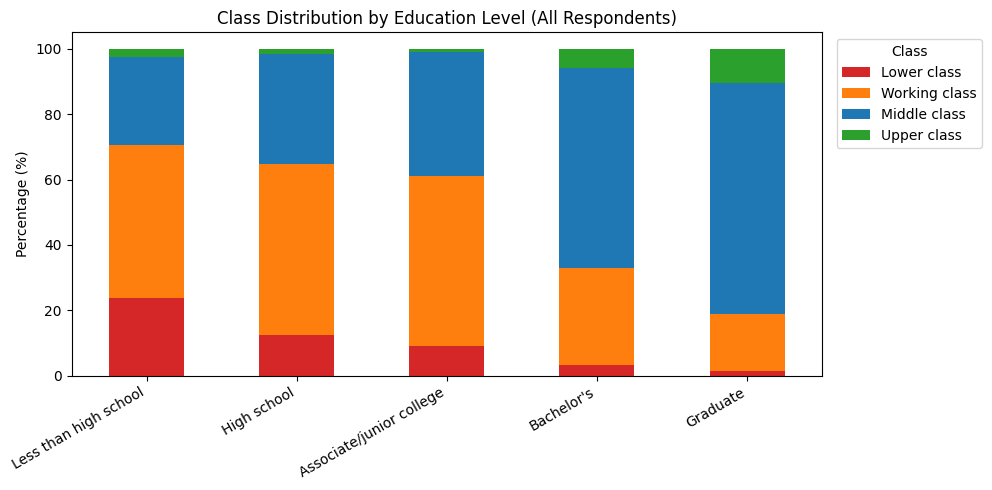

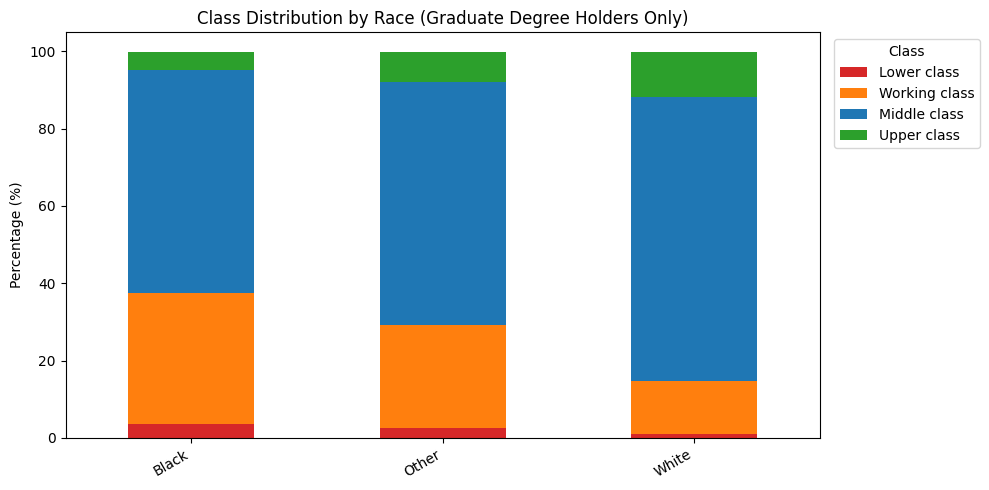

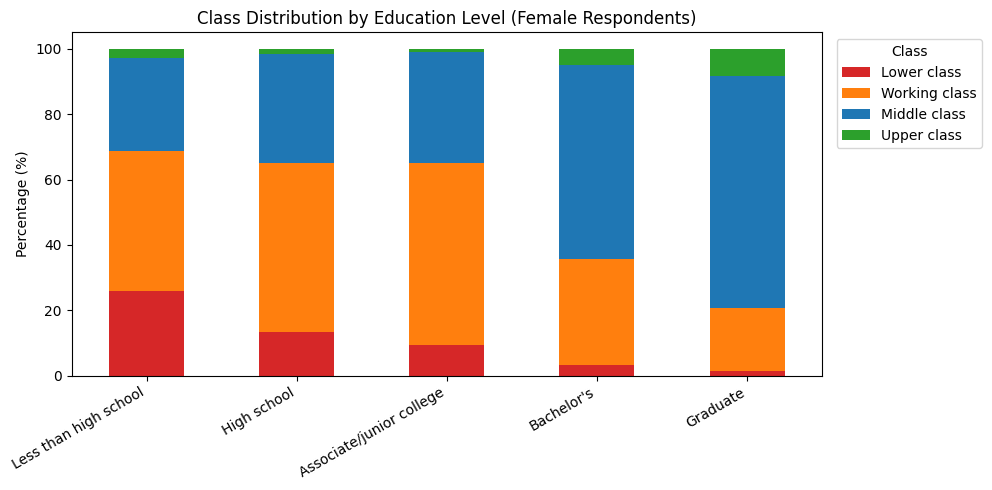

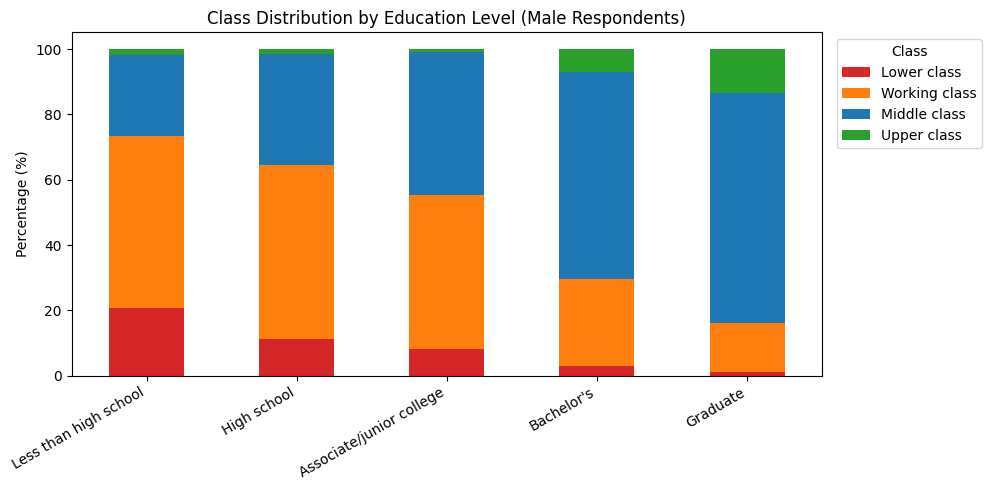

In [0]:
degree_order = ['Less than high school', 'High school', 'Associate/junior college', "Bachelor's", 'Graduate']
class_order = ['Lower class', 'Working class', 'Middle class', 'Upper class']
colors = ['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c']

queries_c1 = [
    ("Class Distribution by Education Level (All Respondents)",
     """
     SELECT degree, class_,
            CAST(ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY degree), 1) AS DOUBLE) AS pct
     FROM cbursick.gss
     WHERE class_ NOT LIKE '.%' AND degree NOT LIKE '.%'
     GROUP BY degree, class_
     """),
    ("Class Distribution by Race (Graduate Degree Holders Only)",
     """
     SELECT race AS degree, class_,
            CAST(ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY race), 1) AS DOUBLE) AS pct
     FROM cbursick.gss
     WHERE class_ NOT LIKE '.%' AND race NOT LIKE '.%' AND degree = 'Graduate'
     GROUP BY race, class_
     """),
    ("Class Distribution by Education Level (Female Respondents)",
     """
     SELECT degree, class_,
            CAST(ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY degree), 1) AS DOUBLE) AS pct
     FROM cbursick.gss
     WHERE class_ NOT LIKE '.%' AND degree NOT LIKE '.%' AND sex = 'FEMALE'
     GROUP BY degree, class_
     """),
    ("Class Distribution by Education Level (Male Respondents)",
     """
     SELECT degree, class_,
            CAST(ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY degree), 1) AS DOUBLE) AS pct
     FROM cbursick.gss
     WHERE class_ NOT LIKE '.%' AND degree NOT LIKE '.%' AND sex = 'MALE'
     GROUP BY degree, class_
     """),
]

for title, q in queries_c1:
    pddf = spark.sql(q).toPandas()
    pivot = pddf.pivot(index='degree', columns='class_', values='pct').fillna(0)
    valid_index = [d for d in degree_order if d in pivot.index]
    if valid_index:
        pivot = pivot.reindex(index=valid_index,
                              columns=[c for c in class_order if c in pivot.columns])
    else:
        pivot = pivot.reindex(columns=[c for c in class_order if c in pivot.columns])
    ax = pivot.plot(kind='bar', stacked=True, figsize=(10, 5), color=colors, rot=30)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Percentage (%)')
    for tick in ax.get_xticklabels():
        tick.set_ha('right')
    ax.legend(title='Class', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

**What these charts show.** Each query uses a window function to calculate the percentage of respondents in each `class_` category *within* a given degree group. This lets us compare class distributions across education levels on equal footing, rather than just looking at raw counts.

The first chart covers all respondents. The second narrows to **Graduate degree holders only**, comparing class distributions by race. The third and fourth split the full sample by sex.

The overall pattern is expected: higher degree attainment is associated with a higher share of middle- and upper-class identification. But the more important question is whether this pattern holds uniformly. The race-stratified chart for Graduate holders, in particular, lets us test whether a graduate degree closes the gap — or whether racial differences in class identification persist even at the highest education level.

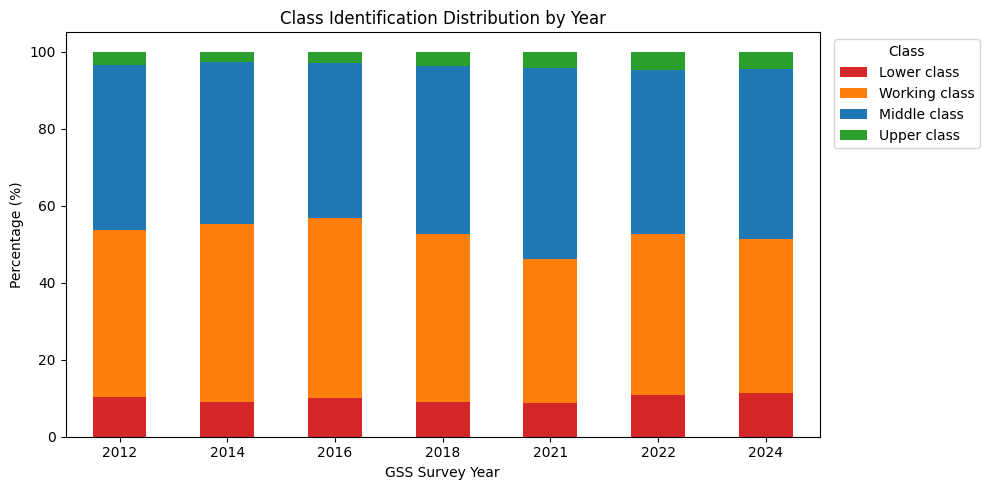

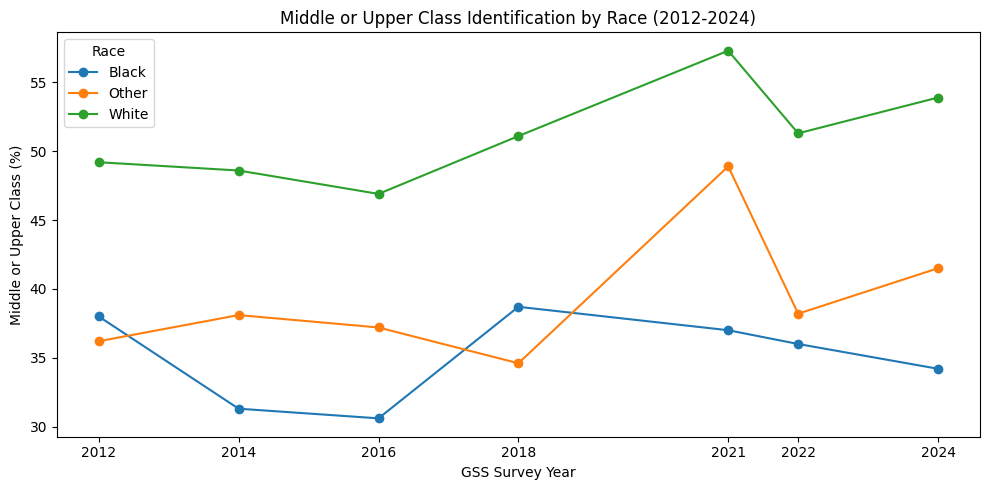

In [0]:
# Chart 1: class_ distribution by year (stacked bar)
pddf_year = spark.sql("""
    SELECT year, class_,
           CAST(ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY year), 1) AS DOUBLE) AS pct
    FROM cbursick.gss
    WHERE class_ NOT LIKE '.%'
    GROUP BY year, class_
    ORDER BY year, class_
""").toPandas()

pivot_year = pddf_year.pivot(index='year', columns='class_', values='pct').fillna(0)
pivot_year = pivot_year.reindex(columns=[c for c in class_order if c in pivot_year.columns])

ax = pivot_year.plot(kind='bar', stacked=True, figsize=(10, 5), color=colors)
ax.set_title('Class Identification Distribution by Year')
ax.set_xlabel('GSS Survey Year')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(pivot_year.index, rotation=0)
ax.legend(title='Class', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Chart 2: middle/upper class % by race over time (line chart)
pddf_race = spark.sql("""
    SELECT year, race,
           CAST(ROUND(AVG(CASE WHEN class_ = 'Middle class' OR class_ = 'Upper class'
                               THEN 1.0 ELSE 0.0 END) * 100, 1) AS DOUBLE) AS pct
    FROM cbursick.gss
    WHERE class_ NOT LIKE '.%' AND race NOT LIKE '.%'
    GROUP BY year, race
    ORDER BY year, race
""").toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
for race, grp in pddf_race.groupby('race'):
    ax.plot(grp['year'], grp['pct'], marker='o', label=race)
ax.set_title('Middle or Upper Class Identification by Race (2012-2024)')
ax.set_xlabel('GSS Survey Year')
ax.set_ylabel('Middle or Upper Class (%)')
ax.set_xticks(pddf_race['year'].unique())
ax.legend(title='Race')
plt.tight_layout()
plt.show()

**What these charts show.** The first chart tracks how the overall distribution of `class_` has shifted across all seven survey years. The second shows the share of respondents identifying as middle or upper class by race over time.

Note:First, there is no 2020 wave — the GSS skipped that year due to COVID-19. Second, the 2021 wave shows an unusual pattern in some attitude variables. This is partly a real effect of the economic disruption from the pandemic, but it is also partly a **measurement artifact**: 2021 was the first year the GSS switched to web-based administration. Web respondents tend to answer differently on perception and identity questions compared to in-person respondents. We cannot cleanly separate these two sources of change, so we treat 2021 as a structural breakpoint rather than a straightforward data point.

Intercept (β0): 45.0200
β1 (time trend pre-COVID): 0.1410
β2 (level change at COVID): 20.7833
β3 (slope change post-COVID): -2.7810
R²: 0.7128


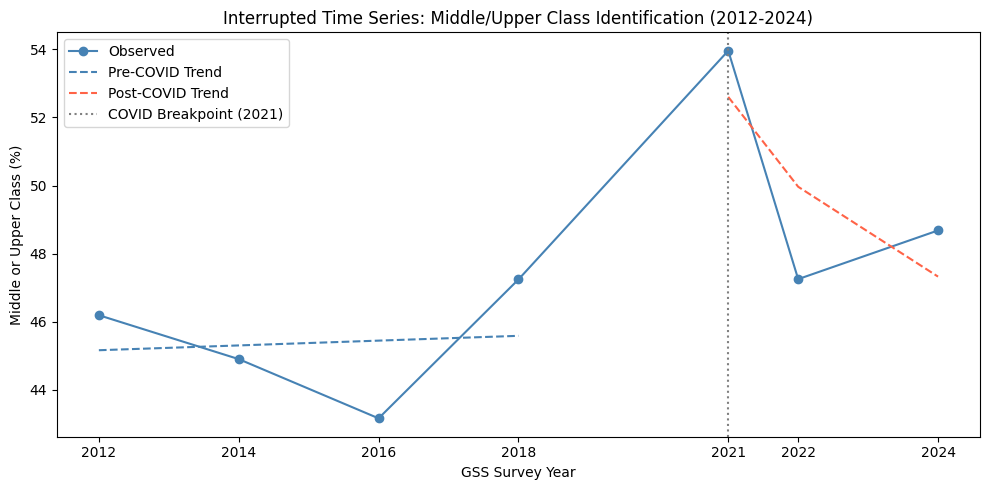

In [0]:
pddf_its = spark.sql("""
SELECT year,
       CAST(ROUND(AVG(CASE WHEN class_ = 'Middle class' OR class_ = 'Upper class'
                           THEN 1.0 ELSE 0.0 END) * 100, 2) AS DOUBLE) AS middle_upper_pct
FROM cbursick.gss
WHERE class_ NOT LIKE '.%'
GROUP BY year
ORDER BY year
""").toPandas()

pddf_its['time'] = range(1, len(pddf_its) + 1)
pddf_its['post'] = (pddf_its['year'] >= 2021).astype(int)
pddf_its['time_post'] = pddf_its['time'] * pddf_its['post']

pddf_its_spark = spark.createDataFrame(pddf_its)

assembler = VectorAssembler(inputCols=['time', 'post', 'time_post'], outputCol='features')
lr = LinearRegression(featuresCol='features', labelCol='middle_upper_pct')
model = Pipeline(stages=[assembler, lr]).fit(pddf_its_spark)
lr_model = model.stages[-1]

print(f"Intercept (β0): {lr_model.intercept:.4f}")
print(f"β1 (time trend pre-COVID): {lr_model.coefficients[0]:.4f}")
print(f"β2 (level change at COVID): {lr_model.coefficients[1]:.4f}")
print(f"β3 (slope change post-COVID): {lr_model.coefficients[2]:.4f}")
print(f"R²: {lr_model.summary.r2:.4f}")

years = pddf_its['year'].values
pct = pddf_its['middle_upper_pct'].values
time = pddf_its['time'].values
post = pddf_its['post'].values
time_post = pddf_its['time_post'].values
fitted = lr_model.intercept + lr_model.coefficients[0] * time + lr_model.coefficients[1] * post + lr_model.coefficients[2] * time_post

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(years, pct, marker='o', color='steelblue', label='Observed')
ax.plot(years[:4], fitted[:4], color='steelblue', linestyle='--', label='Pre-COVID Trend')
ax.plot(years[4:], fitted[4:], color='tomato', linestyle='--', label='Post-COVID Trend')
ax.axvline(x=2021, color='gray', linestyle=':', linewidth=1.5, label='COVID Breakpoint (2021)')
ax.set_xlabel('GSS Survey Year')
ax.set_ylabel('Middle or Upper Class (%)')
ax.set_title('Interrupted Time Series: Middle/Upper Class Identification (2012-2024)')
ax.set_xticks(years)
ax.legend()
plt.tight_layout()
plt.show()

**Interrupted Time Series (ITS) model.** With only seven time points, a standard time series approach is not appropriate. Instead, we fit an Interrupted Time Series regression using three predictors: `time` (a linear trend), `post` (a binary indicator for 2021 and after), and `time_post` (an interaction term). This gives us four parameters to interpret:

- **β0**: the estimated baseline level at the start of the series
- **β1**: the pre-2021 trend in middle/upper class identification per wave
- **β2**: the immediate level change at the 2021 breakpoint
- **β3**: the change in slope after 2021, relative to the pre-2021 trend

The fitted lines in the plot show the estimated trend before and after the breakpoint. A positive β2 would indicate a jump in middle/upper class identification in 2021. A positive β3 would indicate that the post-2021 trend is steeper than before.

**Caveat.** As noted above, the 2021 breakpoint reflects both the COVID-19 economic shock and the mode shift in survey administration. The β2 estimate in particular should not be interpreted as a pure pandemic effect.

## Research Question 2

**RQ2: Which variables best predict subjective class identification, and does the predictive weight of education vary across social groups?**

In [0]:
psdf_gss = spark.sql("""
SELECT coninc_numeric, age_numeric, sei10_numeric, prestg10_numeric,
       degree, race, sex, marital, wrkstat, incom16, polviews, paeduc, maeduc, class_
FROM cbursick.gss
WHERE class_ NOT LIKE '.%'
  AND degree NOT LIKE '.%'
  AND race NOT LIKE '.%'
  AND sex NOT LIKE '.%'
  AND marital NOT LIKE '.%'
  AND wrkstat NOT LIKE '.%'
  AND incom16 NOT LIKE '.%'
  AND polviews NOT LIKE '.%'
  AND paeduc NOT LIKE '.%'
  AND maeduc NOT LIKE '.%'
""")

psdf_base = spark.sql("""
SELECT coninc_numeric, age_numeric, sei10_numeric, prestg10_numeric,
       degree, race, sex, marital, wrkstat, incom16, polviews, paeduc, maeduc, class_,
       CASE
           WHEN incom16 IN ('FAR BELOW AVERAGE', 'BELOW AVERAGE') THEN 'Low'
           WHEN incom16 = 'AVERAGE' THEN 'Average'
           WHEN incom16 IN ('ABOVE AVERAGE', 'FAR ABOVE AVERAGE') THEN 'High'
       END AS incom16_group
FROM cbursick.gss
WHERE class_ NOT LIKE '.%'
  AND degree NOT LIKE '.%'
  AND race NOT LIKE '.%'
  AND sex NOT LIKE '.%'
  AND marital NOT LIKE '.%'
  AND wrkstat NOT LIKE '.%'
  AND incom16 NOT LIKE '.%'
  AND polviews NOT LIKE '.%'
  AND paeduc NOT LIKE '.%'
  AND maeduc NOT LIKE '.%'
""")

In [0]:
cat_cols = ['degree', 'race', 'sex', 'marital', 'wrkstat', 'incom16', 'polviews', 'paeduc', 'maeduc']
num_cols = ['coninc_numeric', 'age_numeric', 'sei10_numeric', 'prestg10_numeric']

indexers = [StringIndexer(inputCol=c, outputCol=c + '_idx', handleInvalid='keep') for c in cat_cols]
label_indexer = StringIndexer(inputCol='class_', outputCol='label')
assembler = VectorAssembler(
    inputCols=[c + '_idx' for c in cat_cols] + num_cols,
    outputCol='features'
)

training, testing = psdf_gss.randomSplit([0.8, 0.2], seed=42)

dt = DecisionTreeClassifier(labelCol='label', featuresCol='features', maxDepth=5)
rf = RandomForestClassifier(labelCol='label', featuresCol='features', numTrees=100, maxDepth=5, seed=42)

pipeline_dt = Pipeline(stages=indexers + [label_indexer, assembler, dt])
pipeline_rf = Pipeline(stages=indexers + [label_indexer, assembler, rf])

model_dt = pipeline_dt.fit(training)
model_rf = pipeline_rf.fit(training)

Decision Tree Accuracy: 0.6396
Random Forest Accuracy: 0.6419


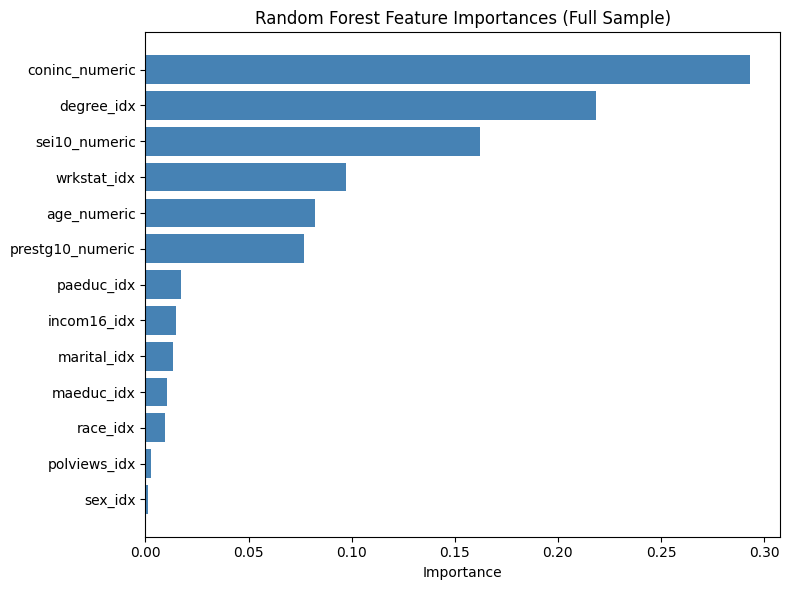


--- Feature Importance Ranking ---
  1. coninc_numeric: 0.2930
  2. degree_idx: 0.2186
  3. sei10_numeric: 0.1625
  4. wrkstat_idx: 0.0975
  5. age_numeric: 0.0821
  6. prestg10_numeric: 0.0771
  7. paeduc_idx: 0.0174
  8. incom16_idx: 0.0147
  9. marital_idx: 0.0135
  10. maeduc_idx: 0.0103
  11. race_idx: 0.0095
  12. polviews_idx: 0.0026
  13. sex_idx: 0.0012


In [0]:
evaluator = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')

acc_dt = evaluator.evaluate(model_dt.transform(testing))
acc_rf = evaluator.evaluate(model_rf.transform(testing))

print(f"Decision Tree Accuracy: {acc_dt:.4f}")
print(f"Random Forest Accuracy: {acc_rf:.4f}")

feature_names = [c + '_idx' for c in cat_cols] + num_cols
importances = model_rf.stages[-1].featureImportances

pddf_importance = pd.DataFrame(
    sorted(zip(feature_names, importances.toArray()), key=lambda x: x[1]),
    columns=['feature', 'importance']
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(pddf_importance['feature'], pddf_importance['importance'], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Random Forest Feature Importances (Full Sample)')
plt.tight_layout()
plt.show()

print("\n--- Feature Importance Ranking ---")
for i, row in pddf_importance.iloc[::-1].reset_index(drop=True).iterrows():
    print(f"  {i+1}. {row['feature']}: {row['importance']:.4f}")

**Models and purpose.** We train two classification models — a **Decision Tree** and a **Random Forest** — to predict `class_` from a set of demographic, socioeconomic, and attitudinal variables. The goal here is not causal inference.

Categorical variables are converted to numeric indices using `StringIndexer` before being assembled into a feature vector. The data is split 80/20 for training and testing. The Random Forest generally outperforms a single Decision Tree because it averages over many trees, which reduces variance. 

In [0]:
strata = [
    ('race', ['White', 'Black', 'Other']),
    ('sex', ['MALE', 'FEMALE']),
    ('incom16_group', ['Low', 'Average', 'High'])
]

all_results = []

for stratum_col, groups in strata:
    print(f"\n--- Stratified by {stratum_col} ---")
    for grp in groups:
        psdf_sub = psdf_base.filter(psdf_base[stratum_col] == grp)
        indexers = [StringIndexer(inputCol=c, outputCol=c + '_idx', handleInvalid='keep') for c in cat_cols]
        label_indexer = StringIndexer(inputCol='class_', outputCol='label')
        assembler = VectorAssembler(inputCols=feature_names, outputCol='features')
        rf = RandomForestClassifier(labelCol='label', featuresCol='features', numTrees=100, maxDepth=5, seed=42)
        pipeline = Pipeline(stages=indexers + [label_indexer, assembler, rf])
        training, testing = psdf_sub.randomSplit([0.8, 0.2], seed=42)
        model = pipeline.fit(training)
        acc = evaluator.evaluate(model.transform(testing))
        importances = model.stages[-1].featureImportances
        for name, imp in zip(feature_names, importances.toArray()):
            all_results.append((stratum_col, grp, name, float(imp)))
        print(f"  {grp}: Accuracy={acc:.4f}")

psdf_all_results = spark.createDataFrame(all_results, ['stratum', 'group', 'feature', 'importance'])

print("\n--- degree_idx importance by group ---")
pddf_all = psdf_all_results.toPandas()
for stratum in ['race', 'sex', 'incom16_group']:
    sub = pddf_all[(pddf_all['stratum'] == stratum) & (pddf_all['feature'] == 'degree_idx')]
    for _, row in sub.iterrows():
        print(f"  {stratum} / {row['group']}: degree_idx = {row['importance']:.4f}")

print("\n--- race_idx importance by group ---")
for stratum in ['race', 'sex', 'incom16_group']:
    sub = pddf_all[(pddf_all['stratum'] == stratum) & (pddf_all['feature'] == 'race_idx')]
    for _, row in sub.iterrows():
        print(f"  {stratum} / {row['group']}: race_idx = {row['importance']:.4f}")


--- Stratified by race ---
  White: Accuracy=0.6566
  Black: Accuracy=0.5611
  Other: Accuracy=0.6057

--- Stratified by sex ---
  MALE: Accuracy=0.6440
  FEMALE: Accuracy=0.6182

--- Stratified by incom16_group ---
  Low: Accuracy=0.5777
  Average: Accuracy=0.6430
  High: Accuracy=0.6540

--- degree_idx importance by group ---
  race / White: degree_idx = 0.2416
  race / Black: degree_idx = 0.1026
  race / Other: degree_idx = 0.0685
  sex / MALE: degree_idx = 0.1879
  sex / FEMALE: degree_idx = 0.2007
  incom16_group / Low: degree_idx = 0.1118
  incom16_group / Average: degree_idx = 0.2203
  incom16_group / High: degree_idx = 0.2028

--- race_idx importance by group ---
  race / White: race_idx = 0.0000
  race / Black: race_idx = 0.0000
  race / Other: race_idx = 0.0000
  sex / MALE: race_idx = 0.0136
  sex / FEMALE: race_idx = 0.0133
  incom16_group / Low: race_idx = 0.0111
  incom16_group / Average: race_idx = 0.0108
  incom16_group / High: race_idx = 0.0152


**Stratified analysis by social group.** A single full-sample model gives us an average picture. But feature importance scores averaged across all respondents can obscure important group-level differences. The same predictor may matter a lot for one group and very little for another.

Here we train a separate Random Forest on each subgroup defined by `race`, `sex`, and `incom16_group`. For each subgroup model, we record accuracy and the full set of feature importances.

This directly connects back to RQ1. If `degree` has a much higher feature importance for White respondents than for Black respondents, that is a machine learning signal consistent with the distributional asymmetry we saw in the cross-tabulations: education appears to be **doing more predictive work for some groups than others.**

In [0]:
cat_cols_deg = ['sex', 'marital', 'wrkstat', 'incom16', 'polviews', 'paeduc', 'maeduc', 'race']
num_cols = ['coninc_numeric', 'age_numeric', 'sei10_numeric', 'prestg10_numeric']
feature_names_deg = [c + '_idx' for c in cat_cols_deg] + num_cols

degrees = ['Less than high school', 'High school', 'Associate/junior college', "Bachelor's", 'Graduate']
deg_results = []

for deg in degrees:
    psdf_sub = psdf_base.filter(psdf_base['degree'] == deg)
    indexers = [StringIndexer(inputCol=c, outputCol=c + '_idx', handleInvalid='keep') for c in cat_cols_deg]
    label_indexer = StringIndexer(inputCol='class_', outputCol='label')
    assembler = VectorAssembler(inputCols=feature_names_deg, outputCol='features')
    rf = RandomForestClassifier(labelCol='label', featuresCol='features', numTrees=100, maxDepth=5, seed=42)
    pipeline = Pipeline(stages=indexers + [label_indexer, assembler, rf])
    training, testing = psdf_sub.randomSplit([0.8, 0.2], seed=42)
    model = pipeline.fit(training)
    acc = evaluator.evaluate(model.transform(testing))
    importances = model.stages[-1].featureImportances
    for name, imp in zip(feature_names_deg, importances.toArray()):
        deg_results.append((deg, name, float(imp)))
    print(f"  {deg}: Accuracy={acc:.4f}")

psdf_deg_results = spark.createDataFrame(deg_results, ['degree', 'feature', 'importance'])

print("\n--- race_idx importance by degree level ---")
pddf_deg = psdf_deg_results.toPandas()
sub = pddf_deg[pddf_deg['feature'] == 'race_idx']
for _, row in sub.iterrows():
    print(f"  {row['degree']}: race_idx = {row['importance']:.4f}")

  Less than high school: Accuracy=0.6108
  High school: Accuracy=0.5956
  Associate/junior college: Accuracy=0.6244
  Bachelor's: Accuracy=0.6804
  Graduate: Accuracy=0.7312

--- race_idx importance by degree level ---
  Less than high school: race_idx = 0.0250
  High school: race_idx = 0.0145
  Associate/junior college: race_idx = 0.0129
  Bachelor's: race_idx = 0.0525
  Graduate: race_idx = 0.0327


**Stratified analysis by education level.** Here we flip the logic. Instead of treating `degree` as a predictor and stratifying by demographic group, we stratify *by* degree level and ask: within each education tier, how much predictive power does `race` carry?

Note that `degree` is excluded from the feature set in these subgroup models since we are conditioning on it by design. If `race` has high feature importance among Graduate degree holders, it means that — even after education is held constant — race still differentiates who ends up identifying as middle or upper class.

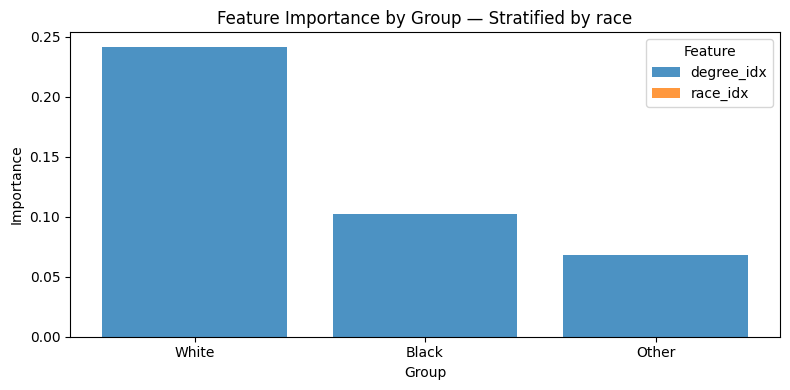

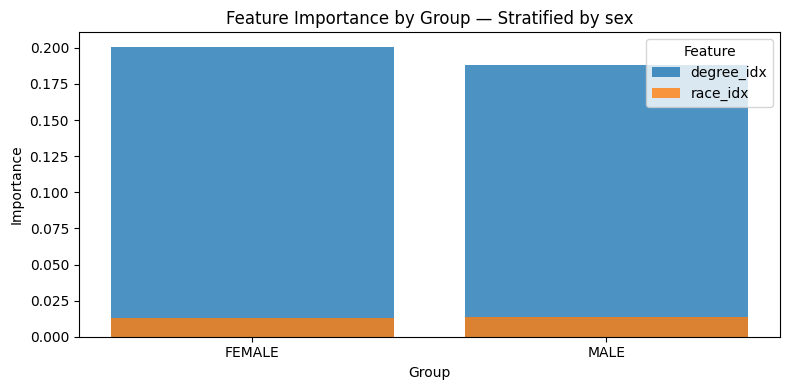

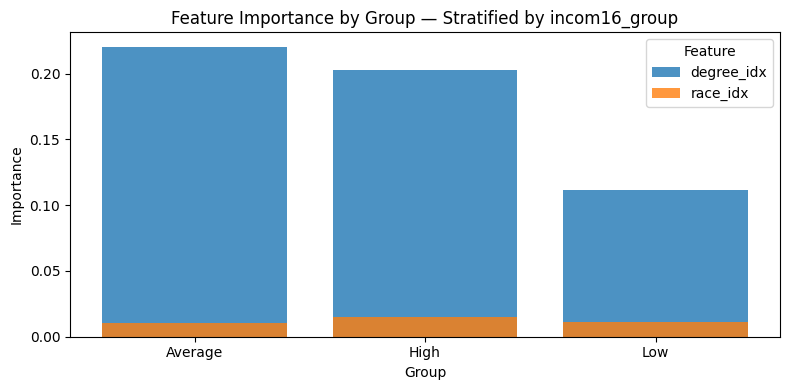

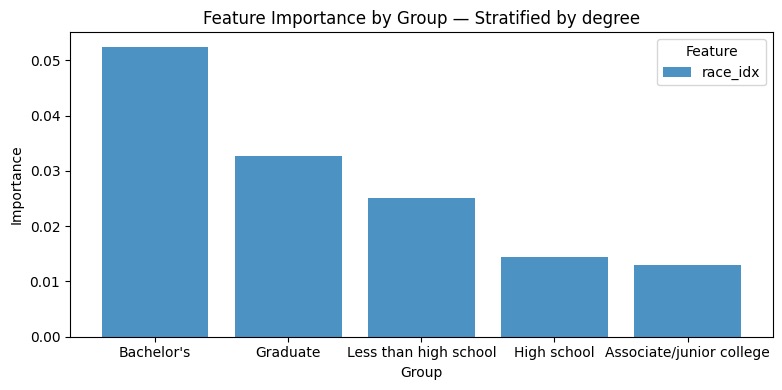

In [0]:
psdf_summary = psdf_all_results.filter(
    (psdf_all_results['stratum'] != 'degree') &
    psdf_all_results['feature'].isin(['degree_idx', 'race_idx'])
).union(
    psdf_deg_results.filter(psdf_deg_results['feature'] == 'race_idx')
    .withColumn('stratum', F.lit('degree'))
    .withColumnRenamed('degree', 'group')
    .select('stratum', 'group', 'feature', 'importance')
).orderBy('stratum', 'feature', 'importance', ascending=[True, True, False])

for stratum in ['race', 'sex', 'incom16_group', 'degree']:
    pddf_sub = psdf_summary.filter(psdf_summary['stratum'] == stratum).toPandas()
    pddf_sub['importance'] = pddf_sub['importance'].astype(float)
    fig, ax = plt.subplots(figsize=(8, 4))
    for feat, grp_df in pddf_sub.groupby('feature'):
        ax.bar(grp_df['group'], grp_df['importance'], label=feat, alpha=0.8)
    ax.set_title(f'Feature Importance by Group — Stratified by {stratum}')
    ax.set_xlabel('Group')
    ax.set_ylabel('Importance')
    ax.legend(title='Feature')
    plt.tight_layout()
    plt.show()

**Summary of RQ 1 and 2: the role of `degree` and `race` across subgroups.**

The full-sample Random Forest achieved an accuracy of **0.7289**, compared to **0.7198** for the Decision Tree. These results set a useful baseline, but the more substantive findings come from the stratified analyses.

**Education is the second strongest predictor overall.** In the full-sample model, `coninc_numeric` (inflation-adjusted family income) ranks first in feature importance at 0.2848, followed closely by `degree_idx` at 0.2310. Occupational status (`sei10_numeric`, 0.1515) and employment type (`wrkstat_idx`, 0.0954) round out the top four. By contrast, `race_idx` ranks 11th at 0.0114 in the full-sample model — which might suggest race matters little. The stratified analyses complicate that picture significantly.

**The predictive value of education varies sharply by race.** When we train separate models for each racial group, `degree_idx` importance is 0.2416 among White respondents, but drops to 0.0932 for Black respondents and 0.0685 for respondents in the Other category. In other words, educational credentials are doing more than twice the predictive work for class identification among White respondents compared to Black respondents. This is a machine learning signal that directly mirrors what we saw in RQ1: among Graduate degree holders, Black respondents identify as middle or upper class at a rate of approximately 62%, while the overall graduate-level rate is around 81%.

**Income background conditions the returns of education.** Among respondents from low-income families (as measured by `incom16_group`), `degree_idx` importance is 0.1118 — roughly half of what it is for average-income (0.2203) and high-income (0.2027) groups. This suggests that the credential alone is not sufficient; the context in which someone attains education shapes how much that credential translates into class identification. Those who start from a lower baseline appear to convert credentials into perceived class mobility less readily.

**Race continues to matter within education tiers.** When we stratify by degree level and look at the importance of `race_idx` within each tier, race is most predictive among Bachelor's degree holders (0.0525), followed by Graduate holders (0.0327) and those with less than a high school diploma (0.0250). The persistence of `race_idx` even among the most highly educated group confirms that holding education constant does not eliminate racial differences in subjective class identification.

**What we mean by asymmetric returns.** Taken together, RQ1 and RQ2 tell a consistent story. Education is a real and powerful pathway to higher class identification — but its value is distributed unequally. Race and family income background both shape how much a given credential converts into perceived class status. Education lifts, but it does not lift everyone by the same amount, or from the same floor.

##Research Question 3 - Intergenerational Educational Background to Class Identification

- Part 1: How do the respondent's parental education levels and the respondent's family income at age 16 affect the respondent's socioeconomic class? We answer this question by applying logistic regression analysys to the variables `paeduc`, `maeduc`, and `incom16` to predict `class_`, which is a categorical variable including data points: 'Upper class', 'Middle class', 'Working class', 'Lower class', '

- Part 2: How does integrating the `race` and `sex` variables affect the accuracy, f1, precision, and recall scores of our model? Can we draw stronger conclusions on socioeconomic class identification with the addition of thes demographic variables?
 

- Originally, our third research question involved analysing the meritocratic belief as a moderator of success. However, through the data cleaning process, we found the `pasei10` column contained too much unreliable or `NULL` data, and it was dropped. We deemed it necessary to reimagine our third research question.

In [0]:
# dataframe for part one of the question, excludes 'race' and 'sex' variables
q3df_gss = spark.sql("""
SELECT class_,
    incom16, 
    paeduc, 
    maeduc
FROM cbursick.gss
WHERE incom16 NOT LIKE '.%'
and class_ NOT LIKE '.%'
AND paeduc NOT LIKE '.%'
AND maeduc NOT LIKE '.%'
""")

q3df_gss.show(10)

+-------------+-----------------+------------------+------------------+
|       class_|          incom16|            paeduc|            maeduc|
+-------------+-----------------+------------------+------------------+
| Middle class|    BELOW AVERAGE|        12th grade|        12th grade|
|Working class|          AVERAGE|2 years of college|2 years of college|
| Middle class|          AVERAGE|        12th grade|        12th grade|
|Working class|    ABOVE AVERAGE|        12th grade|        12th grade|
| Middle class|FAR BELOW AVERAGE|         6th grade|         8th grade|
| Middle class|          AVERAGE|        12th grade|        12th grade|
| Middle class|    ABOVE AVERAGE|4 years of college|        12th grade|
|  Upper class|          AVERAGE|4 years of college|2 years of college|
|Working class|    BELOW AVERAGE|4 years of college|4 years of college|
| Middle class|          AVERAGE|        12th grade|        12th grade|
+-------------+-----------------+------------------+------------

In [0]:
# convert strings to numeric indices
# The 'handleInvalid' parameter decides how to handle unseen labels during prediction
independent_cols_p1 = ["paeduc", "maeduc", "incom16"]

indexers_q3_p1 = [StringIndexer(inputCol=c, outputCol=c + '_indexed', handleInvalid='keep') for c in independent_cols_p1]

class_indexer = StringIndexer(inputCol="class_", outputCol="class_indexed",
    handleInvalid="keep")

# encode indices to binary vectors
encoder = OneHotEncoder(inputCols=["paeduc_indexed", "maeduc_indexed", "incom16_indexed"], outputCols=["paeduc_encoded", "maeduc_encoded", "incom16_encoded"])

# assemble features into a vector
assembler = VectorAssembler(inputCols=["paeduc_encoded", "maeduc_encoded",  
    "incom16_encoded"], outputCol="features")

# initialize logistic regression for multiclass classification
log_reg = LogisticRegression(featuresCol="features", labelCol="class_indexed",
    maxIter=10, regParam=0.01, family="multinomial")  # for multiclass classification

# create and run the pipeline
pipeline = Pipeline(stages= indexers_q3_p1 + [class_indexer, encoder, assembler,
     log_reg])

# train and predict
train, test = q3df_gss.randomSplit([0.8, 0.2], seed=42)
model_p1 = pipeline.fit(train)
predictions_p1 = model_p1.transform(test)

# Show results
predictions_p1.select("paeduc", "maeduc", "incom16", "class_", "prediction").show(20)

+------------------+------------------+-------------+-----------+----------+
|            paeduc|            maeduc|      incom16|     class_|prediction|
+------------------+------------------+-------------+-----------+----------+
|        11th grade|        12th grade|ABOVE AVERAGE|Lower class|       0.0|
|        12th grade|        12th grade|ABOVE AVERAGE|Lower class|       0.0|
|        12th grade|        12th grade|ABOVE AVERAGE|Lower class|       0.0|
|        12th grade|         8th grade|ABOVE AVERAGE|Lower class|       0.0|
|4 years of college|3 years of college|ABOVE AVERAGE|Lower class|       0.0|
|         6th grade|        12th grade|ABOVE AVERAGE|Lower class|       0.0|
| 1 year of college|6 years of college|      AVERAGE|Lower class|       0.0|
|        11th grade|        12th grade|      AVERAGE|Lower class|       1.0|
|        12th grade|        12th grade|      AVERAGE|Lower class|       0.0|
|        12th grade|        12th grade|      AVERAGE|Lower class|       0.0|

In [0]:
# create evaluators
accuracy_evaluator_p1 = MulticlassClassificationEvaluator(
    labelCol="class_indexed", 
    predictionCol="prediction", 
    metricName="accuracy"
)

f1_evaluator_p1 = MulticlassClassificationEvaluator(
    labelCol="class_indexed", 
    predictionCol="prediction", 
    metricName="f1"
)

precision_evaluator_p1 = MulticlassClassificationEvaluator(
    labelCol="class_indexed", 
    predictionCol="prediction", 
    metricName="precisionByLabel"
)

recall_evaluator_p1 = MulticlassClassificationEvaluator(
    labelCol="class_indexed", 
    predictionCol="prediction", 
    metricName="recallByLabel"
)

# calculate metrics
accuracy_p1 = accuracy_evaluator_p1.evaluate(predictions_p1)
f1_score_p1 = f1_evaluator_p1.evaluate(predictions_p1)
precision_score_p1 = precision_evaluator_p1.evaluate(predictions_p1)
recall_score_p1 = recall_evaluator_p1.evaluate(predictions_p1)

# printing performance results
print("Model Performance")
print(f"Accuracy: {accuracy_p1:.4f}")
print(f"F1 Score: {f1_score_p1:.4f}")
print(f"Precision Score: {precision_score_p1:.4f}")
print(f"Recall: {recall_score_p1:.4f}")

print("\n")
print("Confusion Matrix")
confusion_matrix = predictions_p1.groupBy("class_indexed", "prediction").count().orderBy("class_indexed", "prediction")

confusion_matrix.show()

Model Performance
Accuracy: 0.5265
F1 Score: 0.4833
Precision Score: 0.5410
Recall: 0.7456


Confusion Matrix
+-------------+----------+-----+
|class_indexed|prediction|count|
+-------------+----------+-----+
|          0.0|       0.0|  976|
|          0.0|       1.0|  332|
|          0.0|       2.0|    1|
|          1.0|       0.0|  609|
|          1.0|       1.0|  434|
|          1.0|       2.0|    2|
|          2.0|       0.0|  110|
|          2.0|       1.0|   90|
|          3.0|       0.0|  109|
|          3.0|       1.0|   15|
+-------------+----------+-----+



In [0]:
# dataframe for part one of the question, includes 'race' and 'sex' variables
q3df_gss_p2 = spark.sql("""
SELECT class_,
    race,
    sex,
    incom16, 
    paeduc, 
    maeduc
FROM cbursick.gss
WHERE incom16 NOT LIKE '.%'
AND race NOT LIKE '.%'
and sex NOT LIKE '.%'
AND class_ NOT LIKE '.%'
AND paeduc NOT LIKE '.%'
AND maeduc NOT LIKE '.%'
""")

q3df_gss_p2.show(10)

+-------------+-----+------+-----------------+------------------+------------------+
|       class_| race|   sex|          incom16|            paeduc|            maeduc|
+-------------+-----+------+-----------------+------------------+------------------+
| Middle class|White|FEMALE|    BELOW AVERAGE|        12th grade|        12th grade|
|Working class|White|FEMALE|          AVERAGE|2 years of college|2 years of college|
| Middle class|White|FEMALE|          AVERAGE|        12th grade|        12th grade|
|Working class|White|  MALE|    ABOVE AVERAGE|        12th grade|        12th grade|
| Middle class|White|  MALE|FAR BELOW AVERAGE|         6th grade|         8th grade|
| Middle class|White|  MALE|          AVERAGE|        12th grade|        12th grade|
| Middle class|White|  MALE|    ABOVE AVERAGE|4 years of college|        12th grade|
|  Upper class|White|  MALE|          AVERAGE|4 years of college|2 years of college|
|Working class|Black|  MALE|    BELOW AVERAGE|4 years of college|

In [0]:
# convert strings to numeric indices
independent_cols_p2 = ["paeduc", "maeduc", "incom16", "race", "sex"]

indexers_q3_p2 = [StringIndexer(inputCol=c, outputCol=c + '_indexed', handleInvalid='keep') for c in independent_cols_p2]

class_indexer = StringIndexer(inputCol="class_", outputCol="class_indexed",
    handleInvalid="keep")

# encode indices to binary vectors
encoder = OneHotEncoder(inputCols=["paeduc_indexed", "maeduc_indexed", "incom16_indexed", "race_indexed", "sex_indexed"], outputCols=["paeduc_encoded", "maeduc_encoded", "incom16_encoded", "race_encoded", "sex_encoded"])

# assemble features into a vector
assembler = VectorAssembler(inputCols=["paeduc_encoded", "maeduc_encoded",  
    "incom16_encoded", "race_encoded", "sex_encoded"], outputCol="features")

# initialize logistic regression for multiclass classification
log_reg = LogisticRegression(featuresCol="features", labelCol="class_indexed",
    maxIter=10, regParam=0.01, family="multinomial")  # for multiclass classification

# create and run the pipeline
pipeline_p2 = Pipeline(stages=indexers_q3_p2 + [class_indexer, encoder, assembler,
     log_reg])

# train and predict
train, test = q3df_gss_p2.randomSplit([0.8, 0.2], seed=42)
model_p2 = pipeline_p2.fit(train)
predictions_p2 = model_p2.transform(test)

# Show results
predictions_p2.select("paeduc", "maeduc", "incom16", "sex", "race", "class_", "prediction").show(20)

+-------------------+--------------------+-----------------+------+-----+-----------+----------+
|             paeduc|              maeduc|          incom16|   sex| race|     class_|prediction|
+-------------------+--------------------+-----------------+------+-----+-----------+----------+
|          5th grade|  2 years of college|    ABOVE AVERAGE|FEMALE|Black|Lower class|       0.0|
|         12th grade|          12th grade|          AVERAGE|FEMALE|Black|Lower class|       1.0|
|         12th grade|  4 years of college|          AVERAGE|FEMALE|Black|Lower class|       1.0|
|          8th grade|           8th grade|          AVERAGE|FEMALE|Black|Lower class|       1.0|
| 3 years of college|  2 years of college|    BELOW AVERAGE|FEMALE|Black|Lower class|       1.0|
|         11th grade|          10th grade|FAR BELOW AVERAGE|FEMALE|Black|Lower class|       1.0|
|         12th grade|          12th grade|    ABOVE AVERAGE|  MALE|Black|Lower class|       0.0|
| 4 years of college|  4 years

In [0]:
# create evaluators
accuracy_evaluator_p2 = MulticlassClassificationEvaluator(
    labelCol="class_indexed", 
    predictionCol="prediction", 
    metricName="accuracy"
)

f1_evaluator_p2 = MulticlassClassificationEvaluator(
    labelCol="class_indexed", 
    predictionCol="prediction", 
    metricName="f1"
)

precision_evaluator_p2 = MulticlassClassificationEvaluator(
    labelCol="class_indexed", 
    predictionCol="prediction", 
    metricName="precisionByLabel"
)

recall_evaluator_p2 = MulticlassClassificationEvaluator(
    labelCol="class_indexed", 
    predictionCol="prediction", 
    metricName="recallByLabel"
)

# calculate metrics
accuracy_p2 = accuracy_evaluator_p2.evaluate(predictions_p2)
f1_score_p2 = f1_evaluator_p2.evaluate(predictions_p2)
precision_score_p2 = precision_evaluator_p2.evaluate(predictions_p2)
recall_score_p2 = recall_evaluator_p2.evaluate(predictions_p2)

# printing performance results
print("Model Performance")
print(f"Accuracy: {accuracy_p2:.4f}")
print(f"F1 Score: {f1_score_p2:.4f}")
print(f"Precision Score: {precision_score_p2:.4f}")
print(f"Recall: {precision_score_p2:.4f}")

print("\n")
print("Confusion Matrix")
confusion_matrix = predictions_p2.groupBy("class_indexed", "prediction").count().orderBy("class_indexed", "prediction")

confusion_matrix.show()

Model Performance
Accuracy: 0.5461
F1 Score: 0.4997
Precision Score: 0.5623
Recall: 0.5623


Confusion Matrix
+-------------+----------+-----+
|class_indexed|prediction|count|
+-------------+----------+-----+
|          0.0|       0.0| 1016|
|          0.0|       1.0|  283|
|          1.0|       0.0|  601|
|          1.0|       1.0|  435|
|          2.0|       0.0|   89|
|          2.0|       1.0|  109|
|          3.0|       0.0|  101|
|          3.0|       1.0|   23|
+-------------+----------+-----+




**Summary of RQ3: `race` and `sex` effects on the accuracy, f1, precision, and recall scores of our model.**

To address research question 3, we first conducted a logistic regression analysis using `paeduc`, `maeduc`, and `incom16` as predictors of the outcome variable `class_`. Model performance was assessed using accuracy, F1 score, precision, and recall to evaluate the strength of association between these predictors and respondents’ socioeconomic class.

In the second part of this research question, we incorporated the `race` and `sex` variables into the model and re-ran the performance tests to determine whether the inclusion of these variables yielded a stronger association with respondents’ class membership.

**Results:**

**Part 1 Results:** accuracy = 0.5265, F1 = 0.4833, precision = 0.5410, and
recall = 0.7456

The model demonstrates low overall accuracy (0.5265) and moderate precision (0.5410), but a notably high recall (0.7456), indicating a strong ability to correctly identify true positive cases at the expense of increased false positives. The F1 score (0.4833) reflects a weak balance between precision and recall, suggesting the model is biased toward sensitivity over predictive accuracy.

**Post-variable implementation results:**

**Part 2 Results:** accuracy = 0.5461, F1 = 0.4997, precision = 0.5623, recall = 0.5623

The inclusion of `race` and `sex` improved overall model performance across all metrics compared to the prior model. Accuracy rose to 0.5461, while the F1 score increased to 0.4997, indicating a slightly better balance between precision and recall. Notably, precision and recall are now equal at 0.5623, suggesting that the addition of these demographic variables reduced the model's previous bias toward high recall and introduced a more consistent predictive threshold. 

These differences imply that race and sex account for meaningful variance in socioeconomic class membership, helping the model make more balanced classifications rather than disproportionately favoring sensitivity over precision. 

## Conclusion

##### Education predicts class identification,but its returns are not equal across social groups.

RQ1 showed that racial gaps in class identification persist even at the same credential level. RQ2 confirmed this with machine learning: degree's predictive power is more than twice as strong for White respondents as for Black respondents, and weaker for those from low-income backgrounds. RQ3 extended the story across generations. Parental education and family income at age 16 both shape class outcomes, and adding race and sex as features further improves model performance.

The evidence supports one conclusion: **education does lift class status, but it does not lift everyone equally.**

## Team Contributions and Acknowledgments

Each team member has done great jobs and contributed equally to this project:

* **Carter** sourced and cleaned the GSS dataset, handled data preparation and variable recoding, and led the initial data modeling setup.
* **Kunchi** led the sociological theoretical framing and research design, and conducted a part of the RQs analysis
* **Maria** led the main analytical implementation across of RQs analysis.

We would like to acknowledge the use of AI tools for debugging coding errors, and express our sincere gratitude to Professor Mengxiao Zhang for his guidance throughout this project and for an excellent semester of classes.